# Laboratorio 9: Proyecto Final: Agenda Medios

Como hemos visto a lo largo de los laboratorios, extraer datos no es una meta por sí misma, sino el punto de partida del Análisis Crítico. Hoy aplicaremos este concepto sobre la principal noticia del día.

En el Lab 004 generamos un extracto directo de la portada del diario nacional La Nación (`lanacion_portada.json`). En la presente actividad demostraremos las redes tangibles en las que se enmarca la realidad política e informativa de nuestra sociedad actual; es decir, **analizaremos la Agenda Setting y los focos de atención del medio periodístico**.

Al finalizar este cuaderno de ejercicios, empaquetaremos estos hallazgos analíticos utilizando lo aprendido en el Lab 000: diseñaremos un *Dashboard* Interactivo con la librería **Gradio**.

## Consigna 1: Carga y Exploración del Corpus

A partir del archivo JSON suministrado (`lanacion_portada.json`), lea el contenido empleando la librería principal de manejo estadístico `pandas`. Inspeccione el encuadre estructural (forma y primeros 5 renglones) a fines de asegurar la fidelidad del traspaso de registros.

In [2]:
# EJERCICIO: Importar bibliotecas base (pandas y json), leer el archivo e imprimir el encabezado del DataFrame. 
import pandas as pd
import json


In [3]:
df = pd.read_json('../001 - TEO/lanacion_portada.json')

df.head() # por defecto trae los 5 primeros 

,seccion,titulo
0,General,Punto de quiebre. Cuando a Milei se le queman ...
1,General,Viaje a Israel. Milei visitó el Muro de los La...
2,General,Un cambio sorpresivo en la Justicia. El Gobier...
3,General,Hubo 120.000 personas. El ‘cura DJ’ brindó un ...
4,General,Pacto de gobernabilidad. Una advertencia que s...


In [4]:
df.shape

(137, 2)

In [5]:
# Para ver qué secciones hay
nombres_secciones = df['seccion'].unique()
print(f"Las secciones son: {nombres_secciones}")

Las secciones son: <StringArray>
[               'General',             'ACTUALIDAD',    'POLÍTICA Y ECONOMÍA',
               'DEPORTES',               'EL MUNDO',           'MÁS NOTICIAS',
 'HISTORIAS Y PERSONAJES',            'OTROS TEMAS',     'EXPERIENCIA LIVING',
                 'JARDÍN',                'OPINIÓN',              'MOVILIDAD',
             'TECNOLOGÍA',             'MÁS LEÍDAS',            'INVERSIONES',
           'ESPECTÁCULOS',              'LIFESTYLE',     'TE PUEDE INTERESAR']
Length: 18, dtype: str


In [6]:
# Si quiero filtrar por sección
df_filtrado = df[df['seccion'] == 'MÁS LEÍDAS']

# Y ahora mostrar los primeros de esa sección específica
df_filtrado.head()


,seccion,titulo
93,MÁS LEÍDAS,“A la guerra”. Incómodos por el avance de la c...
94,MÁS LEÍDAS,Horóscopo. Cómo será tu semana del 19 al 25 de...
95,MÁS LEÍDAS,“Me voy a almorzar”. ¿El estrecho de Magallane...
96,MÁS LEÍDAS,"""Hagan lío"". La inesperada aparición de García..."
97,MÁS LEÍDAS,Punto de quiebre. Cuando a Milei se le queman ...


In [7]:
# Para crear un cuadro de frecuencias
resumen_secciones = df['seccion'].value_counts().reset_index()

# Renombramos las columnas 
resumen_secciones.columns = ['Sección', 'Cantidad de Notas']

# Mostrar el cuadro
resumen_secciones

,Sección,Cantidad de Notas
0,ESPECTÁCULOS,23
1,ACTUALIDAD,14
2,General,10
3,JARDÍN,10
4,MÁS NOTICIAS,9
5,OTROS TEMAS,9
6,EXPERIENCIA LIVING,9
7,MOVILIDAD,7
8,LIFESTYLE,7
9,OPINIÓN,6


## Consigna 2: Visualización Temática de Agenda Periodística

Con nuestra tabla constituida, buscaremos responder una pregunta clave de investigación: **¿Qué temática decidió priorizar jerárquicamente la línea editorial en su portada de hoy?**

Filtre valores nulos y estructure una representación categórica (ejemplo `sns.barplot()` con orientación horizontal) de modo que exponga de manera irrefutable qué secciones ostentan la mayor cantidad de aparatos editoriales (notas emitidas). Agregue un título informativo y recuerde aplicar principios rigurosos de Data-Ink Ratio.

In [ ]:
# EJERCICIO: Graficar las frecuencias de las secciones (Categoría) del conjunto de noticias.


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
# Limpieza: Eliminamos valores nulos si los hubiera
df_clean = df.dropna(subset=['seccion'])

In [10]:
# Estructurar los datos para el gráfico
conteo = df_clean['seccion'].value_counts().reset_index()
conteo.columns = ['seccion', 'cantidad']


C:\Users\Carlos Estigarribia\AppData\Local\Temp\ipykernel_19500\2600177856.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=conteo, x='cantidad', y='seccion', palette='viridis')


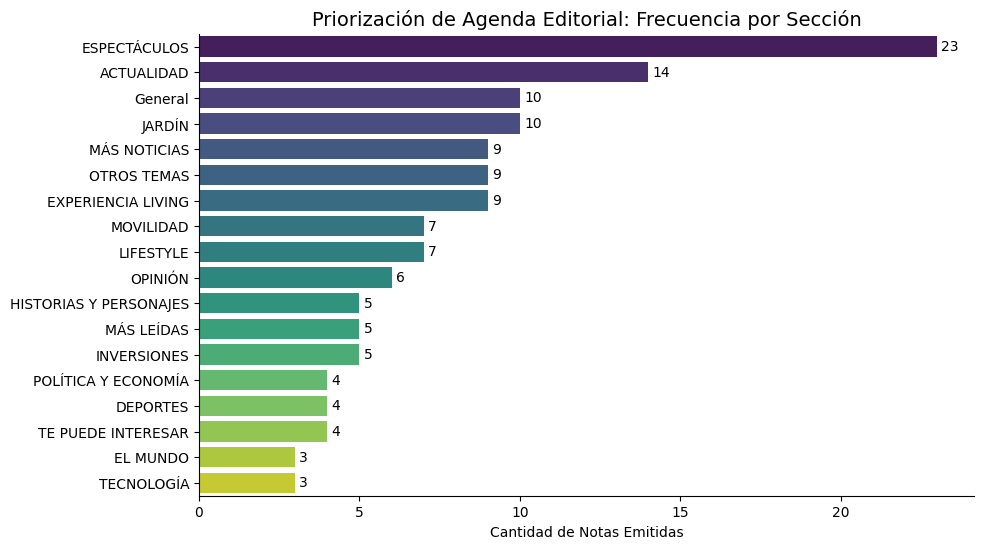

In [11]:
# Visualización con Seaborn (Horizontal y elegante)
plt.figure(figsize=(10, 6))
# ax = para acceder a partes del dibujo
ax = sns.barplot(data=conteo, x='cantidad', y='seccion', palette='viridis')
# para que se vean los numeros de las etiquetas de datos (los totales)
for container in ax.containers:
    ax.bar_label(container, padding=3)

# 3. Estética final
plt.title('Priorización de Agenda Editorial: Frecuencia por Sección', fontsize=14)
plt.xlabel('Cantidad de Notas Emitidas')
plt.ylabel('')
sns.despine()

plt.show()

## Consigna 3: Pesos del Lenguaje (Redes Léxicas)

Con la temática confirmada, deconstruiremos semánticamente esos focos de atención aislando el lenguaje que envuelve al contenido principal. Emplearemos el *Lollipop Chart* abordado en metodologías previas para proyectar las 15 palabras clave con mayor iteración masiva a lo largo de *toda la portada* titular.

Identifique las iteraciones que se formulan más allá de conectores y artículos nulos (*stop words*). ¿Cuál de estos nodos terminológicos monopoliza el marco informativo de la presente fecha?

In [12]:
# EJERCICIO: Extraer el Top 15 de palabras más utilizadas en los títulos (ignorando stop words) y representarlas en un Lollipop Chart.
stopwords_es = {
    "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las", "por", "un", "para", 
    "con", "no", "una", "su", "al", "lo", "como", "más", "pero", "sus", "le", "ya", "o", "este", 
    "sí", "porque", "esta", "entre", "cuando", "muy", "sin", "sobre", "también", "me", "hasta", 
    "hay", "donde", "quien", "desde", "todo", "nos", "durante", "todos", "uno", "les", "ni", 
    "contra", "otros", "ese", "eso", "ante", "ellos", "e", "esto", "mí", "antes", "algunos", 
    "qué", "unos", "yo", "otro", "otras", "otra", "él", "tanto", "esa", "estos", "mucho", "quienes", 
    "nada", "muchos", "cual", "poco", "ella", "estar", "estas", "algunas", "algo", "nosotros", "mi", 
    "mis", "tú", "te", "ti", "tu", "tus", "ellas", "nosotras", "vosotros", "vosotras", "os", "mío", 
    "mía", "míos", "mías", "tuyo", "tuya", "tuyos", "tuyas", "suyo", "suya", "suyos", "suyas", "nuestro", 
    "nuestra", "nuestros", "nuestras", "vuestro", "vuestra", "vuestros", "vuestras", "esos", "esas", 
    "estoy", "estás", "está", "estamos", "estáis", "están", "esté", "estés", "estemos", "estéis", 
    "estén", "estaré", "estarás", "estará", "estaremos", "estaréis", "estarán", "estaría", "estarías", 
    "estaríamos", "estaríais", "estarían", "estaba", "estabas", "estábamos", "estabais", "estaban", 
    "estuve", "estuviste", "estuvo", "estuvimos", "estuvisteis", "estuvieron", "estuviera", "estuvieras", 
    "estuviéramos", "estuvierais", "estuvieran", "estuviese", "estuvieses", "estuviésemos", "estuvieseis", 
    "estuviesen", "estando", "estado", "estada", "estados", "estadas", "soy", "eres", "es", "somos", 
    "sois", "son", "sea", "seas", "seamos", "seáis", "sean", "seré", "serás", "será", "seremos", 
    "seréis", "serán", "sería", "serías", "seríamos", "seríais", "serían", "era", "eras", "éramos", 
    "erais", "eran", "fui", "fuiste", "fue", "fuimos", "fuisteis", "fueron", "fuera", "fueras", 
    "fuéramos", "fuerais", "fueran", "fuese", "fueses", "fuésemos", "fueseis", "fuesen", "siendo", 
    "sido", "tengo", "tienes", "tiene", "tenemos", "tenéis", "tienen", "tenga", "tengas", "tengamos", 
    "tengáis", "tengan", "tendré", "tendrás", "tendrá", "tendremos", "tendréis", "tendrán", "tendría", 
    "tendrías", "tendríamos", "tendríais", "tendrían", "tenía", "tenías", "teníamos", "teníais", 
    "tenían", "tuve", "tuviste", "tuvo", "tuvimos", "tuvisteis", "tuvieron", "tuviera", "tuvieras", 
    "tuviéramos", "tuvierais", "tuvieran", "tuviese", "tuvieses", "tuviésemos", "tuvieseis", 
    "tuviesen", "teniendo", "tenido", "tenida", "tenidos", "tenidas", "hubo", "cómo", "detrás", "000"
}



In [13]:
from collections import Counter
import re

In [14]:
# Unimos todos los títulos en un solo bloque de texto y pasamos a minúsculas
texto_completo = " ".join(df['titulo'].astype(str)).lower()

# Limpiamos puntuación y separamos por palabras
palabras = re.findall(r'\b\w+\b', texto_completo)

# Filtramos, solo dejamos palabras que NO estén en la lista de stopwords
palabras_limpias = [p for p in palabras if p not in stopwords_es] # opción: and len(p) > 2 

# Contamos las 15 más frecuentes
top_15 = Counter(palabras_limpias).most_common(15)

# Creamos un DataFrame para graficarlo fácil
df_top15 = pd.DataFrame(top_15, columns=['Palabra', 'Frecuencia'])
# sumamos 1 para empezar el chart con el n°1
df_top15.index = df_top15.index + 1
df_top15

,Palabra,Frecuencia
1,argentina,10
2,nuevo,8
3,años,7
4,milei,6
5,river,6
6,boca,6
7,departamento,6
8,mundo,5
9,2026,5
10,show,4


In [15]:
# Para entender el contexto donde se utilizó cada palabra del ranking:
def buscar_contexto(palabra):
    """
    Busca una palabra en los títulos y muestra los resultados.
    Ignora mayúsculas/minúsculas.
    """
    # Pasamos la búsqueda a minúsculas para que coincida siempre
    palabra = palabra.lower()
    
    # Filtramos el DataFrame: buscamos la palabra en la columna 'titulo'
    encontrados = df[df['titulo'].str.contains(palabra, case=False, na=False)]
    
    # Mostramos los resultados
    print(f"--- Resultados para la palabra: '{palabra}' ({len(encontrados)} coincidencias) ---")
    
    if len(encontrados) > 0:
        for i, titulo in enumerate(encontrados['titulo'], 1):
            print(f"{i}. {titulo}")
    else:
        print("No se encontraron coincidencias exactas.")


In [16]:
# Ejemplo de uso de la función buscar_contexto:
buscar_contexto("argentina")

--- Resultados para la palabra: 'argentina' (10 coincidencias) ---
1. De Hollywood a Villa Mitre. El Balón: el bar de “Argentina, 1985” que es famoso por su forma de servir cerveza desde los años 50
2. La Repregunta. Alejandro Werner: “La economía argentina va bien, el proceso de recuperación es complicado y los avances van a llevar al crecimiento”
3. “La gente se abrazaba y lloraba”. El festival que transformó a Nápoles en un pedacito de Argentina con asado, fernet y mate
4. "Me da más miedo no lograrlo". De Salta al universo: la argentina de 28 años que sueña con llegar al espacio
5. Del feedlot al fishlot. El negocio productivo que en la Argentina se posiciona como potencia
6. Opinión. Fondo de Asistencia Laboral: una oportunidad que la Argentina no puede desperdiciar
7. Se produce en Campana. Comienza la venta de un nuevo vehículo fabricado en la Argentina
8. “La gente se abrazaba y lloraba”. El festival que transformó a Nápoles en un pedacito de Argentina con asado, fernet y mate


## Consigna Final: Dashboard Dinámico de Sentido con Gradio

Integrar y escalar el diseño. Acaba de confirmar metodológicamente la agenda principal y el vocabulario dominador del periódico entero. Ahora envuélvalo funcionalmente convirtiéndolo en una Interface Web que logre desglosar el contenido respondiendo filtros particulares del investigador.

Deberá programar una Interfaz Gradio (`gr.Interface` o `gr.Blocks`) que exponga un **Desplegable (Dropdown)** poblado con las Secciones halladas (`Política`, `Economía`, `Sociedad`, etc.). 
La selección del usuario invocará una función que:
1. Cribe al DataFrame dejando solamente artículos pertenecientes a dicha sección.
2. Genere dos *outputs* (Salidas): 
    * Una tabla (`gr.Dataframe` o texto) enumerando puros títulos resultantes de esa sección selecta.
    * El gráfico del analizador de pesos (`Lollipop de frecuencias`) re-computado exclusivamente sobre el vocabulario de la sección elegida.

> Al correr la Interfaz, notará instantáneamente cómo el eje material y discursivo muta violentamente de polaridad con el simple acto interactivo de mover de 'Política' a 'Cultura'.

In [17]:
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns

def procesar_dashboard(seccion_elegida):
    # 1. CRIBADO: Filtramos el DataFrame 
    subset = df[df['seccion'] == seccion_elegida].copy()
    
    # SALIDA 1: Tabla con los títulos (solo la columna título)
    tabla_titulos = subset[['titulo']]
    
    # 2. PROCESAMIENTO DE TEXTO (para el Lollipop)
    texto = " ".join(subset['titulo'].astype(str)).lower()
    palabras = re.findall(r'\b\w+\b', texto)
    palabras_limpias = [p for p in palabras if p not in stopwords_es and len(p) > 2]
    top_15 = Counter(palabras_limpias).most_common(15)
    df_loll = pd.DataFrame(top_15, columns=['Palabra', 'Frecuencia']).sort_values(by='Frecuencia')

    # SALIDA 2: Gráfico Lollipop
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.hlines(y=df_loll['Palabra'], xmin=0, xmax=df_loll['Frecuencia'], color='skyblue', alpha=0.7, linewidth=3)
    ax.plot(df_loll['Frecuencia'], df_loll['Palabra'], "o", markersize=10, color='blue', alpha=0.6)
    
    ax.set_title(f"Top 15 Palabras en: {seccion_elegida}")
    ax.set_xlabel("Frecuencia")
    sns.despine()
    plt.tight_layout()
    
    return tabla_titulos, fig

# INTERFAZ GRADIO 
    
with gr.Blocks(title="Dashboard Agenda de Medios") as demo:
    gr.Markdown(f"# Análisis de Sentido - La Nación\nSeleccioná una sección para ver sus títulos y el peso de sus palabras.")
    
    # 1. El selector arriba de todo
    selector = gr.Dropdown(choices=list(df['seccion'].unique()), label="Elegí la Sección")
    
    # 2. La tabla de títulos ocupando el ancho completo
    out_tabla = gr.Dataframe(label="Títulos de la sección", wrap=True, interactive=False)
    
    # 3. El gráfico Lollipop debajo, también a ancho completo
    out_plot = gr.Plot(label="Analizador de Pesos (Lollipop)")

    selector.change(fn=procesar_dashboard, inputs=selector, outputs=[out_tabla, out_plot])

demo.launch()


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
